In [1]:
library(conText)
library(quanteda)
library(dplyr)
library(ggplot2)

conText v3.0.1 successfully loaded. Note this version of the package comes with significant changes to the conText() function.
                        See Quick Start Guide for help getting started and instructions for accessing older versions of the package:
 https://github.com/prodriguezsosa/conText/blob/master/vignettes/quickstart.md

Package version: 4.3.1
Unicode version: 15.0
ICU version: 73.2

Parallel computing: disabled

See https://quanteda.io for tutorials and examples.


Attaching package: ‘dplyr’


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union




In [2]:
all_toks_final <- readRDS("all_toks_ngram_0412.rds")
glove <- readRDS("glove.rds")
khodak <- readRDS("khodakA.rds")

In [3]:
dict_terms <- readRDS("Results_Files/dict_terms_final_0510.rds")

## Build Subsamples

In [4]:
indices <- seq_len(ndoc(all_toks_final))

# Sample
set.seed(7)
subsamples <- sample(1:20, size=length(indices), replace=TRUE,prob=rep(0.05, times=20))

# Extract the subsamples from the tokens object
subsampled_tokens <- split(all_toks_final, subsamples)

In [5]:
subsample_sizes <- sapply(subsampled_tokens, length)

## ALC Embedding

### Ideology

In [134]:
# Helper: tokens -> dem -> dem_group

build_anchor_wv <- function(toks_subsample, pattern, filter_terms = NULL) {
  
  # 1. Build token contexts
  anchor_toks <- tokens_context(
    x       = toks_subsample,
    pattern = pattern,
    window  = 6L
  )
  
  # 2. Optionally filter out contexts where noise terms appear nearby
  if (!is.null(filter_terms)) {
    has_noise <- sapply(anchor_toks, function(ctx) any(filter_terms %in% ctx))
    anchor_toks <- anchor_toks[!has_noise]
  }
  
  # 3. Build DFM
  anchor_dfm <- dfm(anchor_toks)
  
  # 4. Build DEM
  anchor_dem <- dem(
    x                = anchor_dfm,
    pre_trained      = glove,
    transform        = TRUE,
    transform_matrix = khodak,
    verbose          = FALSE
  )
  
  # 5. Group by year — mirrors dem_group(dem, groups = dem@docvars$Year)
  anchor_wv <- dem_group(anchor_dem, groups = anchor_dem@docvars$Year)
  
  return(anchor_wv)
}

In [ ]:
# Pre-compute subsampled liberal & conservative anchors

# Terms to filter from conservative contexts (your original filtering logic)
conservative_noise_terms <- c(
  "estimate", "estimates", "projection", "projections",
  "forecast", "forecasts", "investment", "investments",
  "investor", "investors"
)

liberal_patterns <- c("liberal", "liberals", "liberalism", "liberal-leaning")

conservative_patterns <- c("conservative", "conservatives", 
                            "conservativism", "conservative-leaning")

# One grouped embedding per subsample — computed once, reused for all terms
lib_wv_subsamples <- lapply(1:20, function(n) {
  build_anchor_wv(
    toks_subsample = subsampled_tokens[[n]],
    pattern        = liberal_patterns,
    filter_terms   = NULL                    # no filtering for liberal
  )
})

con_wv_subsamples <- lapply(1:20, function(n) {
  build_anchor_wv(
    toks_subsample = subsampled_tokens[[n]],
    pattern        = conservative_patterns,
    filter_terms   = conservative_noise_terms
  )
})

In [34]:
saveRDS(lib_wv_subsamples, "lib_wv_subsamples.rds")
saveRDS(con_wv_subsamples, "con_wv_subsamples.rds")

In [136]:
lib_wv_subsamples <- readRDS("lib_wv_subsamples.rds")
con_wv_subsamples <- readRDS("con_wv_subsamples.rds")

In [9]:
# Main function: compute cosine similarities for a given term

compute_term_metrics <- function(t) {
  
  years   <- as.character(1980:2024)
  results <- list()
  
  for (n in 1:20) {
    
    # Build term embedding — same pipeline as anchor
    term_wv <- build_anchor_wv(
      toks_subsample = subsampled_tokens[[n]],
      pattern        = t,
      filter_terms   = NULL
    )
    
    # Retrieve precomputed anchor embeddings for this subsample
    lib_wv <- lib_wv_subsamples[[n]]
    con_wv <- con_wv_subsamples[[n]]
    
    for (year in years) {
      
      # All three must have the year for a valid comparison
      year_present <- year %in% term_wv@Dimnames$docs &
                      year %in% lib_wv@Dimnames$docs  &
                      year %in% con_wv@Dimnames$docs
      
      if (year_present) {
        avg_emb <- term_wv[year, ]
        cos_lib <- as.numeric(lsa::cosine(lib_wv[year, ], avg_emb))
        cos_con <- as.numeric(lsa::cosine(con_wv[year, ], avg_emb))
      } else {
        cos_lib <- NA
        cos_con <- NA
      }
      
      results[[length(results) + 1]] <- data.frame(
        term        = t,
        year        = as.integer(year),
        subsample   = n,
        text_n      = subsample_sizes[n],
        cos_liberal = cos_lib,
        cos_con     = cos_con
      )
    }
  }
  
  # Summarise across subsamples — mean and SD as uncertainty estimate
  do.call(rbind, results) %>%
    group_by(term, year) %>%
    mutate(
      cos_liberal_avg = mean(cos_liberal, na.rm = TRUE),
      cos_con_avg     = mean(cos_con,     na.rm = TRUE),
      error_lib = sqrt(text_n) * (cos_liberal - cos_liberal_avg) / sqrt(1350000),
      error_con = sqrt(text_n) * (cos_con     - cos_con_avg)     / sqrt(1350000)
    ) %>%
    summarise(
      cos_liberal_mean  = mean(cos_liberal, na.rm = TRUE),
      cos_liberal_lower = cos_liberal_mean - quantile(error_lib, 0.95, na.rm = TRUE),
      cos_liberal_upper = cos_liberal_mean - quantile(error_lib, 0.05, na.rm = TRUE),
      cos_con_mean      = mean(cos_con,     na.rm = TRUE),
      cos_con_lower     = cos_con_mean - quantile(error_con, 0.95, na.rm = TRUE),
      cos_con_upper     = cos_con_mean - quantile(error_con, 0.05, na.rm = TRUE),
      .groups = "drop"
    )
}

In [ ]:
# Run over all terms by topic, saving as you go
all_metrics_by_topic <- lapply(unique(dict_terms$topic), function(tp) {
  
  topic_terms <- subset(dict_terms, topic == tp)$term
  message("Processing topic: ", tp)
  
  term_metrics <- lapply(topic_terms, compute_term_metrics)
  result <- do.call(rbind, term_metrics)
  
  # Save per-topic checkpoint immediately after completion
  saveRDS(result, paste0("ALC_results_topic/topic_", tp, "_result.rds"))
  message("Saved topic: ", tp)
  
  result
})

### Party

In [9]:
# Pre-compute subsampled Democrat & Republican anchors

Democrat_patterns <- c("democrat", "democrats")

Republican_patterns <- c("republican", "republicans")

# One grouped embedding per subsample — computed once, reused for all terms
dem_wv_subsamples <- lapply(1:20, function(n) {
  build_anchor_wv(
    toks_subsample = subsampled_tokens[[n]],
    pattern        = Democrat_patterns,
    filter_terms   = NULL                    # no filtering for liberal
  )
})

rep_wv_subsamples <- lapply(1:20, function(n) {
  build_anchor_wv(
    toks_subsample = subsampled_tokens[[n]],
    pattern        = Republican_patterns,
    filter_terms   = NULL
  )
})

2997 instances of "democrat" found.
8856 instances of "democrats" found.
2932 instances of "democrat" found.
8765 instances of "democrats" found.
2957 instances of "democrat" found.
8737 instances of "democrats" found.
3147 instances of "democrat" found.
9116 instances of "democrats" found.
3019 instances of "democrat" found.
8881 instances of "democrats" found.
3127 instances of "democrat" found.
9362 instances of "democrats" found.
2978 instances of "democrat" found.
8845 instances of "democrats" found.
2962 instances of "democrat" found.
8716 instances of "democrats" found.
3005 instances of "democrat" found.
9120 instances of "democrats" found.
3108 instances of "democrat" found.
9292 instances of "democrats" found.
3018 instances of "democrat" found.
9153 instances of "democrats" found.
2919 instances of "democrat" found.
8428 instances of "democrats" found.
3071 instances of "democrat" found.
8818 instances of "democrats" found.
2992 instances of "democrat" found.
9117 instances 

In [123]:
saveRDS(dem_wv_subsamples, "dem_wv_subsamples.rds")
saveRDS(rep_wv_subsamples, "rep_wv_subsamples.rds")

In [10]:
dem_wv_subsamples <- readRDS("dem_wv_subsamples.rds")
rep_wv_subsamples <- readRDS("rep_wv_subsamples.rds")

In [11]:
# Main function: compute cosine similarities for a given term

compute_party_metrics <- function(t) {
  
  years   <- as.character(1980:2024)
  results <- list()
  
  for (n in 1:20) {
    
    # Build term embedding — same pipeline as anchor
    term_wv <- build_anchor_wv(
      toks_subsample = subsampled_tokens[[n]],
      pattern        = t,
      filter_terms   = NULL
    )
    
    # Retrieve precomputed anchor embeddings for this subsample
    dem_wv <- dem_wv_subsamples[[n]]
    rep_wv <- rep_wv_subsamples[[n]]
    
    for (year in years) {
      
      # All three must have the year for a valid comparison
      year_present <- year %in% term_wv@Dimnames$docs &
                      year %in% dem_wv@Dimnames$docs  &
                      year %in% rep_wv@Dimnames$docs
      
      if (year_present) {
        avg_emb <- term_wv[year, ]
        cos_dem <- as.numeric(lsa::cosine(dem_wv[year, ], avg_emb))
        cos_rep <- as.numeric(lsa::cosine(rep_wv[year, ], avg_emb))
        cos_diff <- as.numeric(lsa::cosine((dem_wv[year, ] - rep_wv[year,]) , avg_emb))
      } else {
        cos_dem <- NA
        cos_rep <- NA
        cos_diff <- NA
      }
      
      results[[length(results) + 1]] <- data.frame(
        term        = t,
        year        = as.integer(year),
        subsample   = n,
        text_n      = subsample_sizes[n],
        cos_dem     = cos_dem,
        cos_rep     = cos_rep,
        cos_diff    = cos_diff
      )
    }
  }
  
  # Summarise across subsamples — mean and SD as uncertainty estimate
  do.call(rbind, results) %>%
    group_by(term, year) %>%
    mutate(
      cos_dem_avg = mean(cos_dem, na.rm = TRUE),
      cos_rep_avg = mean(cos_rep,  na.rm = TRUE),
      cos_diff_avg = mean(cos_diff, na.rm= TRUE),
      error_dem = sqrt(text_n) * (cos_dem - cos_dem_avg) / sqrt(1350000),
      error_rep = sqrt(text_n) * (cos_rep - cos_rep_avg) / sqrt(1350000),
      error_diff = sqrt(text_n) * (cos_diff - cos_diff_avg) / sqrt(1350000)
    ) %>%
    summarise(
      cos_dem_mean  = mean(cos_dem, na.rm = TRUE),
      cos_dem_lower = cos_dem_mean - quantile(error_dem, 0.95, na.rm = TRUE),
      cos_dem_upper = cos_dem_mean - quantile(error_dem, 0.05, na.rm = TRUE),
      cos_rep_mean  = mean(cos_rep,     na.rm = TRUE),
      cos_rep_lower = cos_rep_mean - quantile(error_rep, 0.95, na.rm = TRUE),
      cos_rep_upper = cos_rep_mean - quantile(error_rep, 0.05, na.rm = TRUE),
      cos_diff_mean = mean(cos_diff, na.rm = TRUE),
      cos_diff_lower = cos_diff_mean - quantile(error_diff, 0.95, na.rm = TRUE),
      cos_diff_upper = cos_diff_mean - quantile(error_diff, 0.05, na.rm = TRUE),
      .groups = "drop"
    )
}

In [12]:
# Run over all terms by topic, saving as you go
lapply(unique(dict_terms$topic), function(tp) {
  
  topic_terms <- subset(dict_terms, topic == tp)$term
  message("Processing topic: ", tp)
  
  term_metrics <- lapply(topic_terms, compute_party_metrics)
  result <- do.call(rbind, term_metrics)
  
  # Save per-topic checkpoint immediately after completion
  saveRDS(result, paste0("ALC_results_party/topic_", tp, "_result.rds"))
  message("Saved topic: ", tp)
  
  head(result)
})

## Recombine

### Term Frequency

In [4]:
dfm <-
    dfm(all_toks_final) %>%
    dfm_trim(min_termfreq = 500)

In [11]:
library(tidyr)

dfm_year <- dfm_group(dfm, 
                      groups = interaction(docvars(dfm, c("Year", "Source")), drop = TRUE))

freq_by_year <- dfm_year %>%
  dfm_select(pattern = dict_terms$term) %>%
  convert(to = "data.frame") %>%
  pivot_longer(
    cols = -doc_id,
    names_to = "term",
    values_to = "frequency"
  )

head(freq_by_year)

doc_id,term,frequency
<chr>,<chr>,<dbl>
1980.New York Times,cooking,263
1980.New York Times,photography,221
1980.New York Times,laboratory,177
1980.New York Times,museum,793
1980.New York Times,solar,185
1980.New York Times,cents,1039


In [13]:
library(stringr)
freq_by_year <-
  freq_by_year %>%
  mutate(
    Year = str_extract(doc_id, "\\d{4}"),
    Source = str_extract(doc_id, "(?<=\\.).*$")
  )

head(freq_by_year)

doc_id,term,frequency,Year,Source
<chr>,<chr>,<dbl>,<chr>,<chr>
1980.New York Times,cooking,263,1980,New York Times
1980.New York Times,photography,221,1980,New York Times
1980.New York Times,laboratory,177,1980,New York Times
1980.New York Times,museum,793,1980,New York Times
1980.New York Times,solar,185,1980,New York Times
1980.New York Times,cents,1039,1980,New York Times


In [14]:
saveRDS(freq_by_year, "freq_by_year_source.rds")

### Merge

In [43]:
freq_by_year <- readRDS("freq_by_year_source.rds")

In [ ]:
freq_by_year <- 
  freq_by_year %>%
  group_by(term, Year) %>%
  summarise(frequency = sum(frequency, na.rm=TRUE)) %>%
  ungroup() %>%
  arrange(frequency)

freq_by_year <- rename(freq_by_year, "year" = Year)

In [10]:
results_df <- do.call(rbind, 
  lapply(list.files("ALC_results_topic", pattern = "topic_.*_result.rds",
                    full.names = TRUE), readRDS))

In [11]:
results_df <-
    results_df %>%
    left_join(dict_terms, by = "term") %>%
    filter(!is.na(label))

In [12]:
freq_by_year$year = as.numeric(freq_by_year$year)

results_df <-
    results_df %>%
    left_join(freq_by_year, by = c("term", "year"))

In [13]:
saveRDS(results_df, "Results_Files/ALC_ideology_results_df.rds")

In [14]:
results_df_party <- do.call(rbind, 
  lapply(list.files("ALC_results_party", pattern = "topic_.*_result.rds",
                    full.names = TRUE), readRDS))

In [15]:
results_df_party <-
    results_df_party %>%
    left_join(dict_terms, by = "term") %>%
    filter(!is.na(label))

In [16]:
results_df_party <-
    results_df_party %>%
    left_join(freq_by_year, by = c("term", "year"))

In [17]:
saveRDS(results_df_party, "Results_Files/ALC_party_results_df.rds")

### Politicization score

In [4]:
results_df <- readRDS("Results_Files/ALC_ideology_results_df.rds")
results_df_party <- readRDS("Results_Files/ALC_party_results_df.rds")

In [5]:
# Create politicization score
results_df <- results_df %>%
    filter(frequency >= 10) %>%   ## appear at least 10 times in any given year
    mutate(pol_score = (cos_liberal_mean + cos_con_mean)/2,
           pol_score_upper = (cos_liberal_upper + cos_con_upper)/2,
           pol_score_lower = (cos_liberal_lower + cos_con_lower)/2) %>%
    mutate(group = "ideology") %>%
    select("term", "year", "topic", "label", "pol_score", "pol_score_upper", "pol_score_lower", "group")

results_df_party <- results_df_party %>%
    filter(frequency >= 10) %>%
    mutate(pol_score = (cos_dem_mean + cos_rep_mean)/2,
           pol_score_upper = (cos_dem_upper + cos_rep_upper)/2,
           pol_score_lower = (cos_dem_lower + cos_rep_lower)/2) %>%
    mutate(group = "party") %>%
    select("term", "year", "topic", "label", "pol_score", "pol_score_upper", "pol_score_lower", "group")

### Create bigger categories

In [6]:
results_df_cat <- 
    rbind(results_df, results_df_party) %>%
    mutate(Category = case_when(
      label %in% c("Abortion", "Gender", "LGBTQ", "Marriage", "Parenting") ~ "Gender and Family",
      label %in% c("Catholicism", "Religion") ~ "Religion",
      label %in% c("Minority", "Native_American", "Racial", "Confederate", "Immigration") ~ "Race and Immigration",
      label %in% c("Campaigns & Donors", "Protest", "PublicOpinion", "Senate", "Elections") ~ "Politics",
      label %in% c("CriminalJustice", "Investigation", "Criminal", "Burglary", 
                   "Homicide", "Police") ~ "Crime and Policing",
      label %in% c("Constitution_Law", "Judicial", "Lawsuit", "SupremeCourt") ~ "Legal Institution",
      label %in% c("Higher_Education", "Education") ~ "Education",
      label %in% c("Science") ~ "Science",
      label %in% c("Gun_Control") ~ "Gun",
      label %in% c("Bankruptcy", "Banks", "Commodity_Market", "Corporate", "CorporateFinance",
                   "Earnings", "ExecutiveCompensation", "Financial", "Investing", "Money_Markets",
                   "Retail", "Securities",
                   "Stock_market", "Foreign_exchange") ~ "Financial Market",
      label %in% c("Welfare & Poverty", "Taxation", "Economics", "Agriculture", "Business",
                   "Economy", "Fiscal", "Labor", "Workers", "MonetaryPolicy", "Trade") ~ "Economic Issues",
      label %in% c("Housing", "Urban_development", "Mortgage", "Architecture") ~ "Housing",
      label %in% c("China", "Espionage", "Latin_America", "Middle_East",
                   "MiddleEastConflict", "Military", "NuclearArms", "Terrorism", "Russia & Ukraine") ~ "Foreign Affairs",
      label %in% c("ClimateChange", "Disaster", "Air Pollution",
                   "Weather", "Wildfires") ~ "Environment",
      label %in% c("Healthcare", "Hospital", "MentalHealth", "Nutrition", "Pharmaceuticals",
                   "Substance Abuse", "Vaccine", "Disease") ~ "Health",
      label %in% c("Art",  "Broadway",  "Classical_Music", 
                      "Museum", "Fashion", 
                      "Literature", "Movie", "Music") ~ "Creative Arts",
      label %in% c("Festival", "TravelIndustry", "Horticulture", "Nature", "Gaming") ~ "Leisure",
      label %in% c("Culinary", "Dining",  "Wine", "Beverage") ~ "Food & Drinks",
      label %in% c("Journalism", "Radio", "Television", "TV_Entertainment") ~ "Media",
      label %in% c("AmericanFootball", "Baseball", "NBA", "NFL", "Boxing",
                   "CollegeSports", "Golf", "NHL", "Soccer",  "Tennis") ~ "Sports",
      label %in% c("Electricity", "Energy", "Postal_service",  "Telecommunications", "Water") ~ "Infrastructure",
      label %in% c("Maritime",  "Mass_Transit", "Airline", "Automotive",
                    "Railroad", "Traffic", "Transportation") ~ "Transportation",
      label %in% c("Animal", "Marine_Biology",  "Wildlife") ~ "Animals",
      label %in% c("Home", "Household", "Cooking") ~ "Home",
      label == "Space" ~ "Outer Space",
      TRUE ~ "Other"))

## Category Level Graphs

### Overall Graph

In [7]:
results_df_cat %>%
    group_by(year, group) %>%
    summarise(value_avg = mean(pol_score, na.rm=TRUE)) %>%
    ungroup() %>%
    arrange(value_avg)

`summarise()` has grouped output by 'year'. You can override using the
`.groups` argument.


year,group,value_avg
<dbl>,<chr>,<dbl>
1993,ideology,0.1413386
1993,party,0.1456055
1995,ideology,0.1478854
1991,ideology,0.1485418
1990,party,0.1489857
1996,ideology,0.1494918
1992,ideology,0.1496029
1990,ideology,0.1514055
1994,ideology,0.1516522


`summarise()` has grouped output by 'year'. You can override using the
`.groups` argument.
`geom_smooth()` using formula = 'y ~ s(x, bs = "cs")'


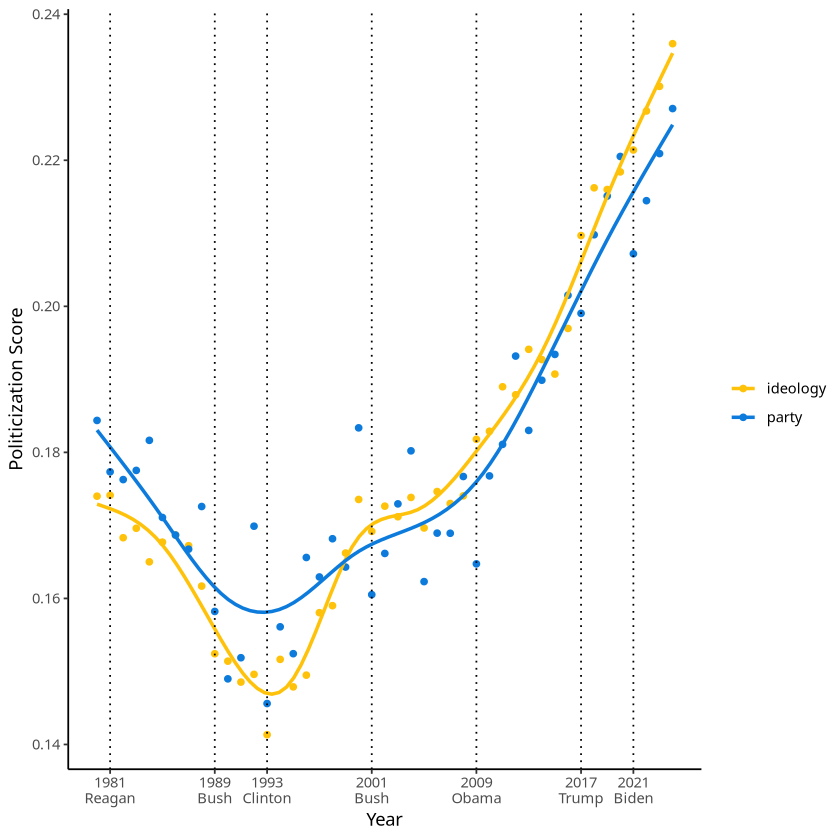

In [8]:
president <- data.frame(xintercepts = c(1981, 1989, 1993, 2001, 2009, 2017, 2021))

results_df_cat %>%
    group_by(year, group) %>%
    summarise(value_avg = mean(pol_score, na.rm=TRUE)) %>%
    ungroup() %>%
    ggplot(aes(x= year, y=value_avg, color = group)) +
    geom_point() +
    geom_smooth(method = "gam", se=FALSE) +
    geom_vline(data = president, aes(xintercept = xintercepts), linetype = "dotted") +
    scale_x_continuous(
        breaks = c(1981, 1989, 1993, 2001, 2009, 2017, 2021),
        labels = c("1981\nReagan", "1989\nBush", "1993\nClinton",
                   "2001\nBush", "2009\nObama", "2017\nTrump", "2021\nBiden")) +
    scale_color_manual(values = c("#FFC20A", "#0C7BDC")) +
    theme_classic() +
    labs(x = "Year",
         y = "Politicization Score") + 
    guides(color = guide_legend(title = "")) +
    theme(plot.title = element_text(size= 20), 
          plot.subtitle=element_text(size=18), 
          strip.text = element_text(size = 15))

In [24]:
ggsave("Figure 1_26-06-17-politicization_overall.png")

Saving 6.67 x 6.67 in image
`geom_smooth()` using formula = 'y ~ s(x, bs = "cs")'


### Regression

In [90]:
results_df_cat_reg <-
   results_df_cat %>%
   group_by(year, label, Category, group) %>%
   summarise(
    value_avg   = mean(pol_score,   na.rm = TRUE),
    value_upper = mean(pol_score_upper, na.rm = TRUE),
    value_lower = mean(pol_score_lower, na.rm = TRUE),
    .groups = "drop"
  ) %>%
  mutate(year0 = year - 1980)

In [10]:
length(unique(results_df_cat_reg$label))

[1] 131

In [28]:
saveRDS(results_df_cat_reg, "Results_Files/results_df_label_combined.rds")

In [11]:
library(lme4)
model_ideo <- lme4::lmer(value_avg ~ year0 + (year0|label), data=subset(results_df_cat_reg, group == "ideology"))
model_party <- lme4::lmer(value_avg ~ year0 + (year0|label), data=subset(results_df_cat_reg, group == "party"))

Loading required package: Matrix

Warning message in checkConv(attr(opt, "derivs"), opt$par, ctrl = control$checkConv, :
“Model failed to converge with max|grad| = 0.0291452 (tol = 0.002, component 1)”


In [30]:
library(texreg)
texreg(list(model_ideo, model_party), digits = 4,
       file = "26-06-17-models.tex")

Version:  1.39.3
Date:     2023-11-09
Author:   Philip Leifeld (University of Essex)

Consider submitting praise using the praise or praise_interactive functions.
Please cite the JSS article in your publications -- see citation("texreg").

The table was written to the file '26-06-17-models.tex'.




In [87]:
## Add a quadratic year term and compare to the linear model above
model_ideo_quad  <- lme4::lmer(value_avg ~ year0 + I(year0^2) + (year0|label),
                                data = subset(results_df_cat_reg, group == "ideology"))
model_party_quad <- lme4::lmer(value_avg ~ year0 + I(year0^2) + (year0|label),
                                data = subset(results_df_cat_reg, group == "party"))

Warning message in checkConv(attr(opt, "derivs"), opt$par, ctrl = control$checkConv, :
“Model failed to converge with max|grad| = 0.177852 (tol = 0.002, component 1)”
Warning message in checkConv(attr(opt, "derivs"), opt$par, ctrl = control$checkConv, :
“Model failed to converge with max|grad| = 0.00384985 (tol = 0.002, component 1)”


In [83]:
library(texreg)
texreg(list(model_ideo_quad, model_party_quad), digits = 4,
       file = "26-08-17-models_quadratic.tex")

Version:  1.39.3
Date:     2023-11-09
Author:   Philip Leifeld (University of Essex)

Consider submitting praise using the praise or praise_interactive functions.
Please cite the JSS article in your publications -- see citation("texreg").

The table was written to the file '26-08-17-models_quadratic.tex'.




In [31]:
category_list <- 
    results_df_cat_reg %>%
    select(label, Category) %>%
    distinct() %>%
    arrange(Category)

write.csv(category_list, "category_list.csv")

In [12]:
category_year <- results_df_cat %>%
  group_by(year, Category, group) %>%
  summarise(
    value_avg   = mean(pol_score,   na.rm = TRUE),
    value_upper = mean(pol_score_upper, na.rm = TRUE),
    value_lower = mean(pol_score_lower, na.rm = TRUE),
    .groups = "drop"
  ) %>%
  mutate(year0 = year - 1980)

head(category_year)

year,Category,group,value_avg,value_upper,value_lower,year0
<dbl>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>
1980,Animals,ideology,0.1692543,0.1930696,0.1447428,0
1980,Animals,party,0.1780599,0.2009267,0.1539552,0
1980,Creative Arts,ideology,0.1835854,0.2066478,0.1600739,0
1980,Creative Arts,party,0.1760519,0.1974455,0.1545960,0
1980,Crime and Policing,ideology,0.1534839,0.1756288,0.1299309,0
1980,Crime and Policing,party,0.1893566,0.2115006,0.1667408,0


### Graph - scope

In [91]:
results_df_cat_reg <-
    results_df_cat_reg %>%
    group_by(label, group) %>%
    mutate(high_pol = case_when(mean(value_avg[year >= 1980 & year <= 1989], na.rm = TRUE) >= 0.2 ~ "High (>0.2)",
                                mean(value_avg[year >= 1980 & year <= 1989], na.rm = TRUE) <= 0.15 ~ "Low (<0.15)",
                                TRUE ~ "Medium (0.15-0.2)")) %>%
    ungroup() 

`summarise()` has grouped output by 'high_pol', 'year'. You can override using
the `.groups` argument.
`geom_smooth()` using formula = 'y ~ s(x, bs = "cs")'


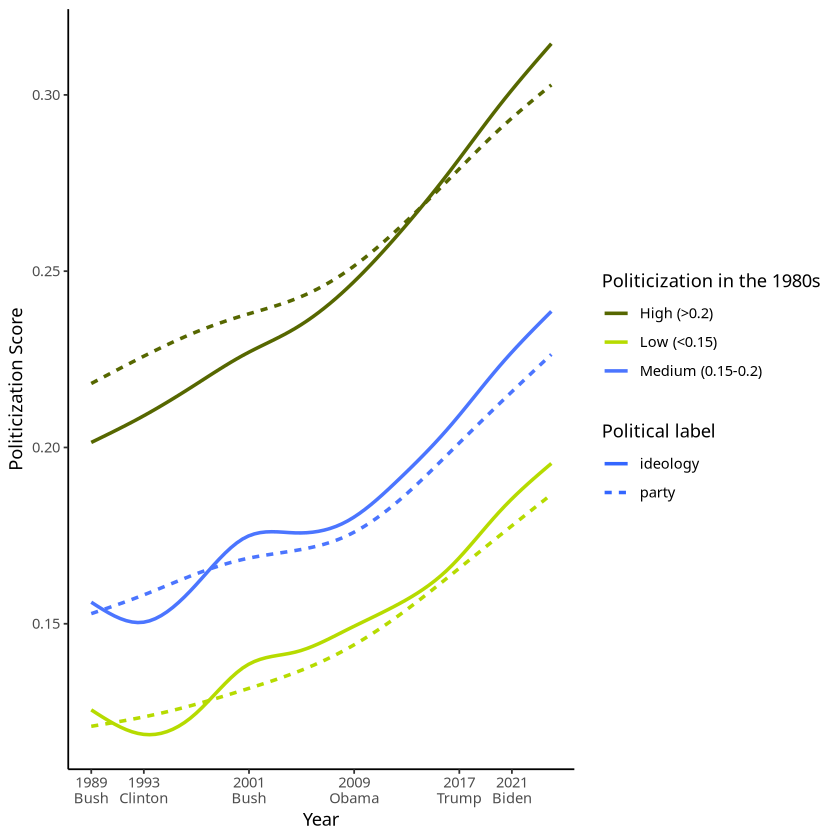

In [92]:
results_df_cat_reg %>%
    filter(year >= 1989) %>%
    group_by(high_pol, year, group) %>%
    summarise(value_avg = mean(value_avg, na.rm=TRUE)) %>%
    ungroup() %>%
    ggplot(aes(x=year, y=value_avg, color = high_pol, linetype = group)) +
    geom_smooth(method = "gam", se=FALSE) +
    scale_x_continuous(
        breaks = c(1989, 1993, 2001, 2009, 2017, 2021),
        labels = c("1989\nBush", "1993\nClinton",
                   "2001\nBush", "2009\nObama", "2017\nTrump", "2021\nBiden")) +
    theme_classic() +
    scale_color_manual(values = c("#566700", "#B6DB00", "#4B75FF")) +
    labs(x = "Year",
         y = "Politicization Score") + 
    guides(linetype = guide_legend(title = "Political label"),
           color = guide_legend(title = "Politicization in the 1980s")) +
    theme(plot.title = element_text(size= 20), 
          plot.subtitle=element_text(size=18))

In [93]:
ggsave("politicization_overall_strat_new.png")

Saving 6.67 x 6.67 in image
`geom_smooth()` using formula = 'y ~ s(x, bs = "cs")'


### Graph - Most and Least Politicized

In [15]:
polscore_cat_rawvalues <- 
  category_year %>%
  group_by(Category, group) %>%
  summarise(
    early_value  = mean(value_avg[year >= 1980 & year <= 1989], na.rm = TRUE),
    early_upper  = mean(value_upper[year >= 1980 & year <= 1989], na.rm = TRUE),
    early_lower  = mean(value_lower[year >= 1980 & year <= 1989], na.rm = TRUE),
    late_value  = mean(value_avg[year >= 2015 & year <= 2024], na.rm = TRUE),
    late_upper  = mean(value_upper[year >= 2015 & year <= 2024], na.rm = TRUE),
    late_lower  = mean(value_lower[year >= 2015 & year <= 2024], na.rm = TRUE)
  ) %>%
  ungroup() %>%
  arrange(desc(late_value))

`summarise()` has grouped output by 'Category'. You can override using the
`.groups` argument.


In [ ]:
write.csv(polscore_cat_rawvalues, "polscore_cat_rawvalues.csv")

In [16]:
order_ideo <-
    polscore_cat_rawvalues %>% 
    filter(group == "ideology") %>%
    arrange(desc(late_value))

order_ideo

Category,group,early_value,early_upper,early_lower,late_value,late_upper,late_lower
<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
Politics,ideology,0.2667628,0.2952037,0.23826642,0.3570081,0.3824392,0.3328080
Race and Immigration,ideology,0.1930134,0.2191475,0.16657365,0.2912368,0.3164049,0.2669965
Legal Institution,ideology,0.1909677,0.2148489,0.16638976,0.2797255,0.3039171,0.2558072
Gender and Family,ideology,0.1915723,0.2174219,0.16488859,0.2774249,0.3030988,0.2520820
Religion,ideology,0.1979746,0.2260281,0.16869263,0.2726480,0.3015900,0.2440622
Education,ideology,0.1975751,0.2219295,0.17252206,0.2684997,0.2915616,0.2455866
Media,ideology,0.1849812,0.2093990,0.15988111,0.2368775,0.2601780,0.2134560
Gun,ideology,0.1545486,0.1794907,0.12891678,0.2325758,0.2568624,0.2090145
Economic Issues,ideology,0.2044817,0.2286169,0.18003016,0.2288385,0.2515467,0.2060987


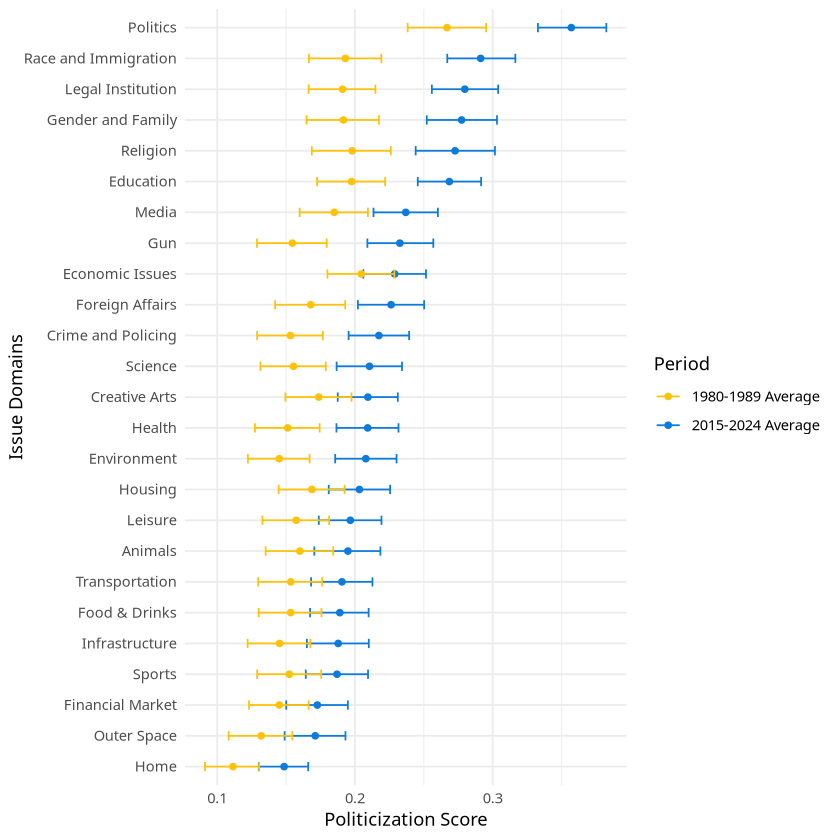

In [17]:
category_year %>%
  group_by(Category) %>%
  filter(group == "ideology") %>%
  summarise(
    late_value  = mean(value_avg[year >= 2015 & year <= 2024], na.rm = TRUE),
    early_value = mean(value_avg[year >= 1980 & year <= 1989], na.rm = TRUE),
    late_upper  = mean(value_upper[year >= 2015 & year <= 2024], na.rm = TRUE),
    late_lower  = mean(value_lower[year >= 2015 & year <= 2024], na.rm = TRUE),
    early_upper = mean(value_upper[year >= 1980 & year <= 1989], na.rm = TRUE),
    early_lower = mean(value_lower[year >= 1980 & year <= 1989], na.rm = TRUE)
  ) %>%
  ungroup() %>%
  mutate(early_rank = min_rank(desc(early_value)),
         late_rank = min_rank(desc(late_value))) %>%
  ggplot(aes(y = reorder(Category, late_value))) +
  geom_point(aes(x = late_value, color = "2015-2024 Average"),
             position = position_dodge(width = 0.3)) +
  geom_errorbar(aes(xmin = late_lower, xmax = late_upper,
                    color = "2015-2024 Average"), width = 0.3) +
  geom_point(aes(x = early_value, color = "1980-1989 Average")) +
  geom_errorbar(aes(xmin = early_lower, xmax = early_upper,
                    color = "1980-1989 Average"), width = 0.3) +
  scale_alpha_manual(values = c(0.5, 1.0)) +
  scale_linetype_manual(values = c("dashed", "solid")) +
  scale_color_manual(values = c("#FFC20A", "#0C7BDC")) +
  labs(x = "Politicization Score",
       y = "Issue Domains") +
  guides(color = guide_legend(title = "Period")) +
  theme_minimal(base_size = 11) +
  theme(plot.title = element_text(size= 20), 
          plot.subtitle=element_text(size=18), 
          strip.text = element_text(size = 15))

In [125]:
ggsave("Figure3_politicization_cat_period_ideo.png", width =6.5, height = 7)

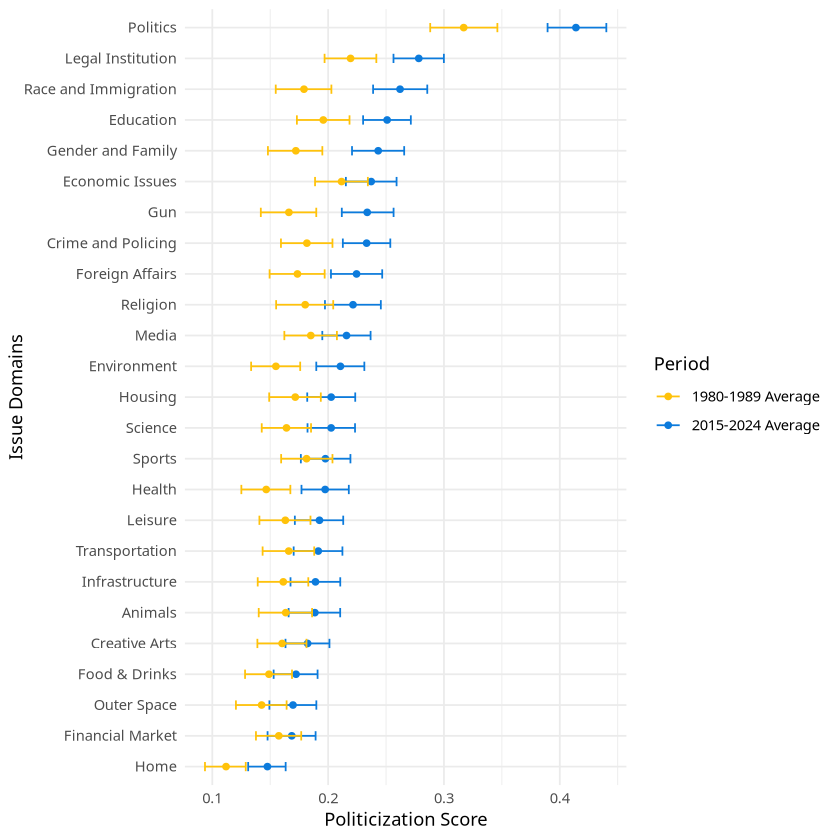

In [18]:
category_year %>%
  group_by(Category) %>%
  filter(group == "party") %>%
  summarise(
    late_value  = mean(value_avg[year >= 2015 & year <= 2024], na.rm = TRUE),
    early_value = mean(value_avg[year >= 1980 & year <= 1989], na.rm = TRUE),
    late_upper  = mean(value_upper[year >= 2015 & year <= 2024], na.rm = TRUE),
    late_lower  = mean(value_lower[year >= 2015 & year <= 2024], na.rm = TRUE),
    early_upper = mean(value_upper[year >= 1980 & year <= 1989], na.rm = TRUE),
    early_lower = mean(value_lower[year >= 1980 & year <= 1989], na.rm = TRUE)
  ) %>%
  ungroup() %>%
  mutate(early_rank = min_rank(desc(early_value)),
         late_rank = min_rank(desc(late_value))) %>%
  ggplot(aes(y = reorder(Category, late_value))) +
  geom_point(aes(x = late_value, color = "2015-2024 Average"),
             position = position_dodge(width = 0.3)) +
  geom_errorbar(aes(xmin = late_lower, xmax = late_upper,
                    color = "2015-2024 Average"), width = 0.3) +
  geom_point(aes(x = early_value, color = "1980-1989 Average")) +
  geom_errorbar(aes(xmin = early_lower, xmax = early_upper,
                    color = "1980-1989 Average"), width = 0.3) +
  scale_alpha_manual(values = c(0.5, 1.0)) +
  scale_linetype_manual(values = c("dashed", "solid")) +
  scale_color_manual(values = c("#FFC20A", "#0C7BDC")) +
  labs(x = "Politicization Score",
       y = "Issue Domains") +
  guides(color = guide_legend(title = "Period")) +
  theme_minimal() +
  theme(plot.title = element_text(size= 20), 
          plot.subtitle=element_text(size=18), 
          strip.text = element_text(size = 15))

In [123]:
ggsave("Figure4_politicization_cat_period_party.png", width = 6.5, height = 7)

### Graph - Change over Time

In [40]:
## Correlation between two trends

library(tidyr)

cor_results <- category_year %>%
  select(year, Category, group, value_avg) %>%
  pivot_wider(
    names_from = group,
    values_from = value_avg
  ) %>%
  group_by(Category) %>%
  summarise(
    correlation = cor(ideology, party, use = "complete.obs"),
    n_years = sum(complete.cases(ideology, party))
  )

cor_results %>%
    arrange(correlation)


Attaching package: ‘tidyr’


The following object is masked from ‘package:texreg’:

    extract


The following objects are masked from ‘package:Matrix’:

    expand, pack, unpack




Category,correlation,n_years
<chr>,<dbl>,<int>
Sports,0.8316993,45
Media,0.8406907,45
Creative Arts,0.8745739,45
Financial Market,0.8793212,45
Religion,0.8794472,45
Animals,0.8923253,45
Leisure,0.8948544,45
Outer Space,0.9059446,45
Transportation,0.9139178,45


In [41]:
library(lme4)

### Mixed effects model

model_cat_1 <- lme4::lmer(value_avg ~ year0 + (year0 | Category), 
                        data = category_year %>% filter(group == "ideology"))

model_cat_2 <- lme4::lmer(value_avg ~ year0 + (year0 | Category), 
                        data = category_year %>% filter(group == "party"))

Warning message in checkConv(attr(opt, "derivs"), opt$par, ctrl = control$checkConv, :
“Model failed to converge with max|grad| = 1.11296 (tol = 0.002, component 1)”
Warning message in checkConv(attr(opt, "derivs"), opt$par, ctrl = control$checkConv, :
“Model failed to converge with max|grad| = 1.15494 (tol = 0.002, component 1)”


In [42]:
### Extract category-specific slopes

category_intercept_1 <- coef(model_cat_1)$Category %>%
  tibble::rownames_to_column("Category") %>%
  arrange(desc(year0)) %>%
  rename("slope" = year0)  %>%
  filter(Category != "Other") %>%
  mutate(group = "ideology")

category_intercept_2 <- coef(model_cat_2)$Category %>%
  tibble::rownames_to_column("Category") %>%
  arrange(desc(year0)) %>%
  rename("slope" = year0)  %>%
  filter(Category != "Other") %>%
  mutate(group = "party")

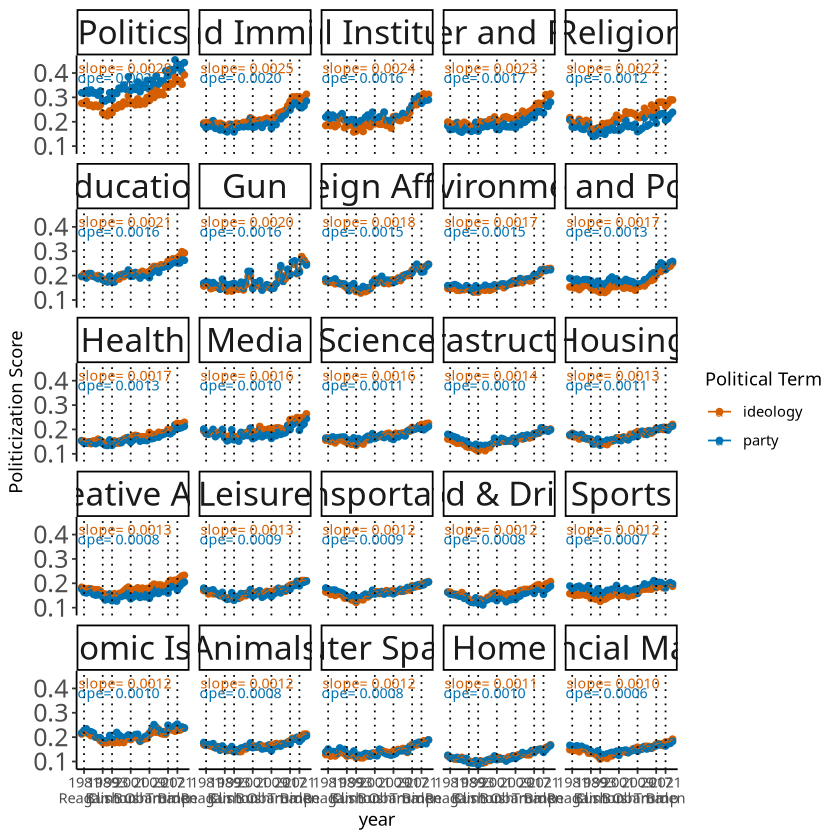

In [43]:
## presidential inauguration year
president <- data.frame(xintercepts = c(1981, 1989, 1993, 2001, 2009, 2017, 2021))

category_year %>%
  ggplot(aes(x = year, y = value_avg, color = group)) +
  geom_point() +
  geom_line(aes(color=group)) +
  geom_vline(data = president, aes(xintercept = xintercepts), linetype = "dotted") +
  scale_x_continuous(
    breaks = c(1981, 1989, 1993, 2001, 2009, 2017, 2021),
    labels = c("1981\nReagan", "1989\nBush", "1993\nClinton",
               "2001\nBush", "2009\nObama", "2017\nTrump", "2021\nBiden")
  ) +
  theme_classic() +
  geom_text(data= category_intercept_1, 
            aes(label=paste("ideology slope=", format(round(slope, digits = 4), scientific = FALSE))),
            x = 1985, y = 0.42, size = 3) +
  geom_text(data= category_intercept_2, 
            aes(label=paste("party slope=", format(round(slope, digits = 4), scientific = FALSE))),
            x = 1985, y = 0.38, size = 3) +
  scale_color_manual(values = c("#D55E00", "#0072B2")) +
  facet_wrap(~factor(Category, category_intercept_1$Category), ncol = 5) +
  labs(y = "Politicization Score",
       color = "Political Term") +
  theme(
    strip.text    = element_text(size = 20),
    axis.text.y   = element_text(size = 15),
  )

In [44]:
ggsave("Figure2_politicization_fulltrend.png", height =20, width = 24)

## Topic Level Graphs

In [45]:
graph_topic <- function(g){

results_graph <- 
  results_df_cat_reg %>%
  filter(!label %in% c("Party", "Campaigns & Donors", "Protest", "PublicOpinion", "Senate", "Elections")) %>%
  filter(group == g) %>%
  group_by(label) %>%
  summarise(
    late_value  = mean(value_avg[year >= 2015 & year <= 2024], na.rm = TRUE),
    early_value = mean(value_avg[year >= 1980 & year <= 1989], na.rm = TRUE),
    late_upper  = mean(value_upper[year >= 2015 & year <= 2024], na.rm = TRUE),
    late_lower  = mean(value_lower[year >= 2015 & year <= 2024], na.rm = TRUE),
    early_upper = mean(value_upper[year >= 1980 & year <= 1989], na.rm = TRUE),
    early_lower = mean(value_lower[year >= 1980 & year <= 1989], na.rm = TRUE)
  ) %>%
  ungroup() %>%
  mutate(diff = late_value - early_value)

bind_rows(
  results_graph %>% slice_max(order_by = diff, n = 15),
  results_graph %>% slice_min(order_by = diff, n = 15)
) %>%
  ggplot(aes(y = reorder(label, diff))) +
  geom_point(aes(x = late_value,  shape = "2015-2024 Average", color = "2015-2024 Average")) +
  geom_errorbar(aes(xmin = late_lower, xmax = late_upper,
                    color = "2015-2024 Average"), width = 0.3) +
  geom_point(aes(x = early_value, shape = "1980-1989 Average", color = "1980-1989 Average")) +
  geom_errorbar(aes(xmin = early_lower, xmax = early_upper,
                    color = "1980-1989 Average"), width = 0.3) +
  geom_hline(yintercept = 15.5, linetype = "dashed", color = "gray50", size =1) +
  scale_color_manual(values = c("#FFC20A", "#0C7BDC")) +
  labs(x = "Politicization Score",
       y = "Topic") +
  guides(shape = guide_legend(title = ""),
         color = guide_legend(title = "")) +
  theme_minimal()
}

Warning message:
“Using `size` aesthetic for lines was deprecated in ggplot2 3.4.0.
ℹ Please use `linewidth` instead.”


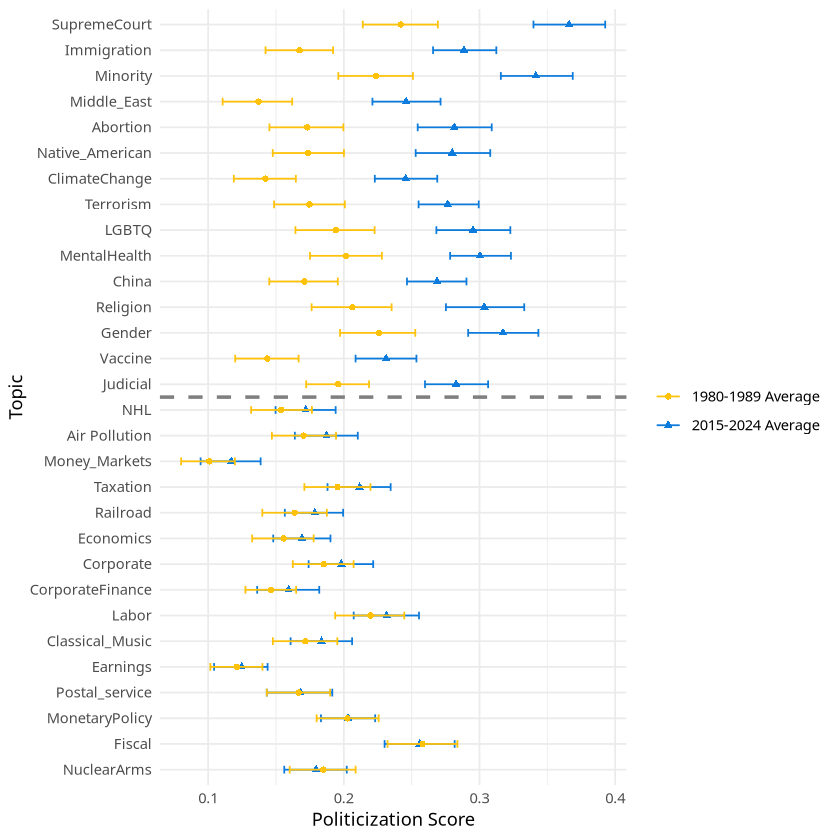

In [46]:
graph_topic("ideology")

In [47]:
ggsave("26-05-29-politicization_topic_period_ideo.png", height = 6.5, width =7)

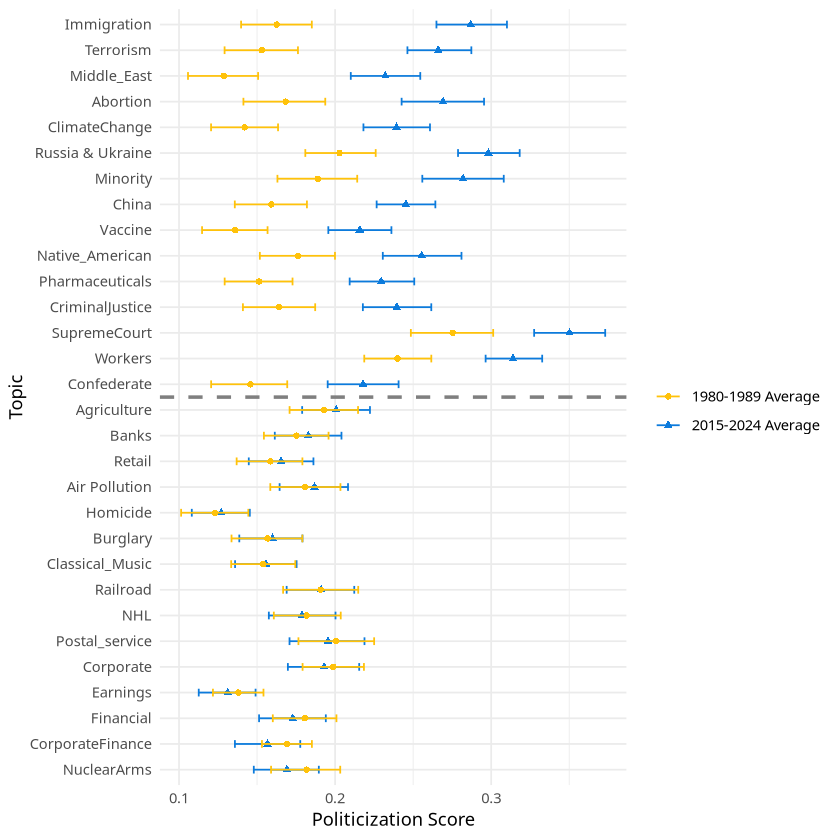

In [48]:
graph_topic("party")

In [49]:
ggsave("26-05-29-politicization_topic_period_party.png", height = 6.5, width =7)

### Specific Issue Domain

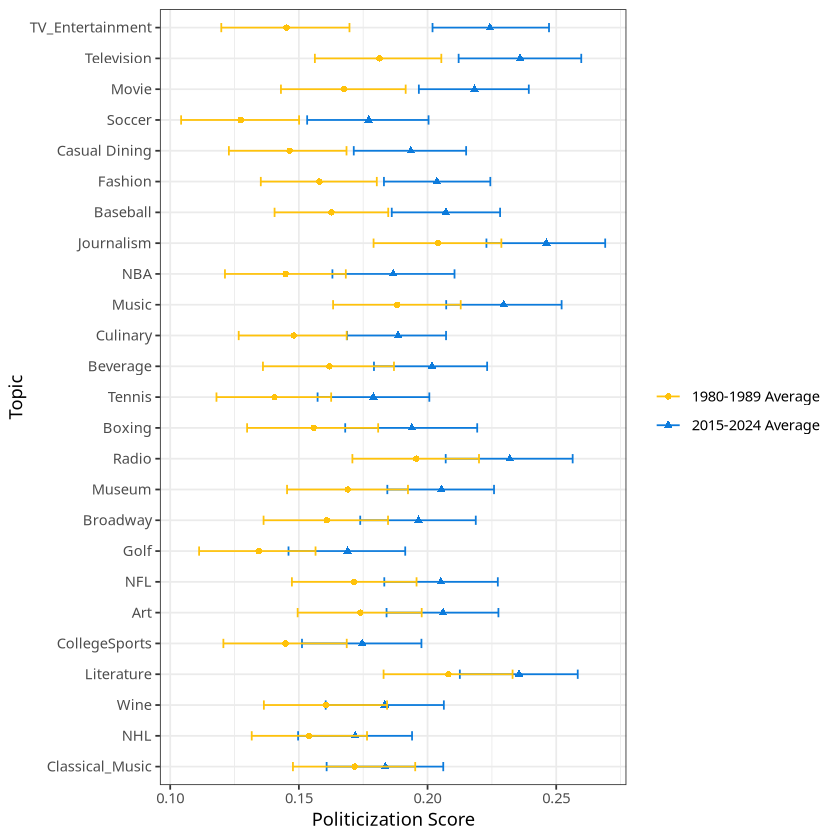

In [66]:
results_df_cat_reg %>%
  filter(Category %in% c("Creative Arts", "Media", "Sports", "Food & Drinks")) %>%
  mutate(label = ifelse(label == "Dining", "Casual Dining", label)) %>%
  filter(group == "ideology") %>%
  group_by(label) %>%
  summarise(
    late_value  = mean(value_avg[year >= 2015 & year <= 2024], na.rm = TRUE),
    early_value = mean(value_avg[year >= 1980 & year <= 1989], na.rm = TRUE),
    late_upper  = mean(value_upper[year >= 2015 & year <= 2024], na.rm = TRUE),
    late_lower  = mean(value_lower[year >= 2015 & year <= 2024], na.rm = TRUE),
    early_upper = mean(value_upper[year >= 1980 & year <= 1989], na.rm = TRUE),
    early_lower = mean(value_lower[year >= 1980 & year <= 1989], na.rm = TRUE)
  ) %>%
  ungroup() %>%
  mutate(diff = late_value - early_value) %>%
  ggplot(aes(y = reorder(label, diff))) +
  geom_point(aes(x = late_value,  shape = "2015-2024 Average", color = "2015-2024 Average")) +
  geom_errorbar(aes(xmin = late_lower, xmax = late_upper,
                    color = "2015-2024 Average"), width = 0.3) +
  geom_point(aes(x = early_value, shape = "1980-1989 Average", color = "1980-1989 Average")) +
  geom_errorbar(aes(xmin = early_lower, xmax = early_upper,
                    color = "1980-1989 Average"), width = 0.3) +
  scale_color_manual(values = c("#FFC20A", "#0C7BDC")) +
  labs(x = "Politicization Score",
       y = "Topic") +
  guides(shape = guide_legend(title = ""),
         color = guide_legend(title = "")) +
  theme_bw(base_size = 11)

In [53]:
ggsave("26-06-17-politicization_lifestyle_period.png", height = 6.5, width= 7)

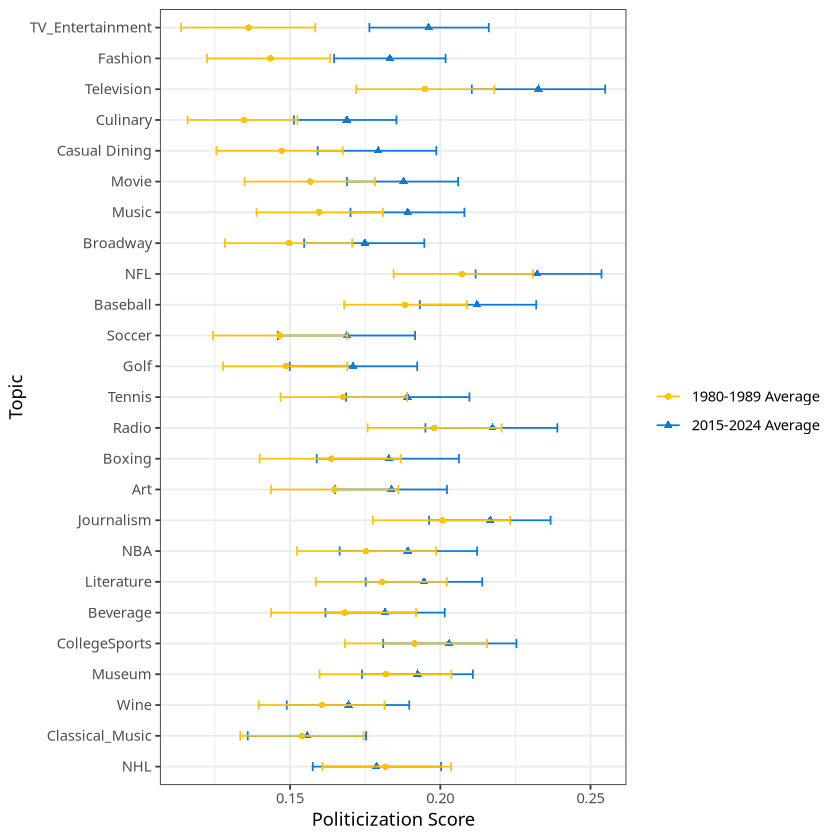

In [67]:
results_df_cat_reg %>%
  filter(Category %in% c("Creative Arts", "Media", "Sports", "Food & Drinks")) %>%
  mutate(label = ifelse(label == "Dining", "Casual Dining", label)) %>%
  filter(group == "party") %>%
  group_by(label) %>%
  summarise(
    late_value  = mean(value_avg[year >= 2015 & year <= 2024], na.rm = TRUE),
    early_value = mean(value_avg[year >= 1980 & year <= 1989], na.rm = TRUE),
    late_upper  = mean(value_upper[year >= 2015 & year <= 2024], na.rm = TRUE),
    late_lower  = mean(value_lower[year >= 2015 & year <= 2024], na.rm = TRUE),
    early_upper = mean(value_upper[year >= 1980 & year <= 1989], na.rm = TRUE),
    early_lower = mean(value_lower[year >= 1980 & year <= 1989], na.rm = TRUE)
  ) %>%
  ungroup() %>%
  mutate(diff = late_value - early_value) %>%
  ggplot(aes(y = reorder(label, diff))) +
  geom_point(aes(x = late_value,  shape = "2015-2024 Average", color = "2015-2024 Average")) +
  geom_errorbar(aes(xmin = late_lower, xmax = late_upper,
                    color = "2015-2024 Average"), width = 0.3) +
  geom_point(aes(x = early_value, shape = "1980-1989 Average", color = "1980-1989 Average")) +
  geom_errorbar(aes(xmin = early_lower, xmax = early_upper,
                    color = "1980-1989 Average"), width = 0.3) +
  scale_color_manual(values = c("#FFC20A", "#0C7BDC")) +
  labs(x = "Politicization Score",
       y = "Topic") +
  guides(shape = guide_legend(title = ""),
         color = guide_legend(title = "")) +
  theme_bw(base_size = 11)

In [55]:
ggsave("26-06-17-politicization_lifestyle_period_party.png", height = 6.5, width= 7)

In [56]:
graph_topic_full <- function(cat){

model_lab_1 <- lme4::lmer(value_avg ~ year0 + (year0 | label), 
                        data = results_df_cat_reg  %>% filter(group == "ideology" & Category %in% cat))

model_lab_2 <- lme4::lmer(value_avg ~ year0 + (year0 | label), 
                        data = results_df_cat_reg  %>% filter(group == "party" & Category %in% cat))

### Extract category-specific slopes

label_intercept_1 <- coef(model_lab_1)$label %>%
  tibble::rownames_to_column("label") %>%
  arrange(desc(year0)) %>%
  rename("slope" = year0)  %>%
  mutate(group = "ideology")

label_intercept_2 <- coef(model_lab_2)$label %>%
  tibble::rownames_to_column("label") %>%
  arrange(desc(year0)) %>%
  rename("slope" = year0)  %>%
  mutate(group = "party")

## presidential inauguration year
president <- data.frame(xintercepts = c(1981, 1989, 1993, 2001, 2009, 2017, 2021))

results_df_cat_reg  %>% 
  filter(Category %in% cat) %>%
  ggplot(aes(x = year, y = value_avg, color = group)) +
  geom_point() +
  geom_line(aes(color=group)) +
  geom_vline(data = president, aes(xintercept = xintercepts), linetype = "dotted") +
  scale_x_continuous(
    breaks = c(1981, 1989, 1993, 2001, 2009, 2017, 2021),
    labels = c("1981\nReagan", "1989\nBush", "1993\nClinton",
               "2001\nBush", "2009\nObama", "2017\nTrump", "2021\nBiden")
  ) +
  theme_classic() +
  geom_text(data= label_intercept_1, 
            aes(label=paste("ideology slope=\n", format(round(slope, digits = 4), scientific = FALSE))),
            x = 1985, y = 0.25, size = 2.5) +
  geom_text(data= label_intercept_2, 
            aes(label=paste("party slope=\n", format(round(slope, digits = 4), scientific = FALSE))),
            x = 1985, y = 0.21, size = 2.5) +
  facet_wrap(~factor(label, label_intercept_1$label), ncol = 5) +
  scale_color_manual(values = c("#FFC20A", "#0C7BDC")) +
  labs(y = "Politicization Score",
       color = "Political Term") +
  theme(
    plot.title    = element_text(size = 20),
    plot.subtitle = element_text(size = 18),
    strip.text    = element_text(size = 15)
  )

}

Warning message in checkConv(attr(opt, "derivs"), opt$par, ctrl = control$checkConv, :
“Model failed to converge with max|grad| = 0.0108932 (tol = 0.002, component 1)”
Warning message in checkConv(attr(opt, "derivs"), opt$par, ctrl = control$checkConv, :
“Model failed to converge with max|grad| = 0.0644414 (tol = 0.002, component 1)”


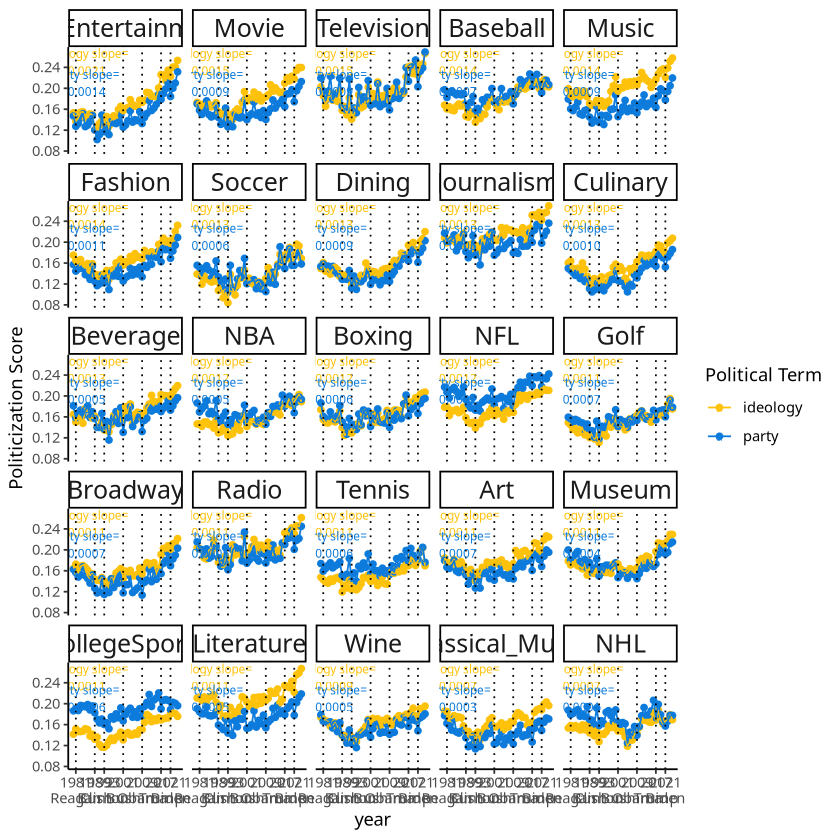

In [57]:
graph_topic_full(c("Creative Arts", "Media", "Sports", "Food & Drinks"))

In [58]:
ggsave("26-06-17-politicization_lifestyle.png", height = 20, width= 24)

### Specific Terms

`summarise()` has grouped output by 'term', 'group'. You can override using the
`.groups` argument.


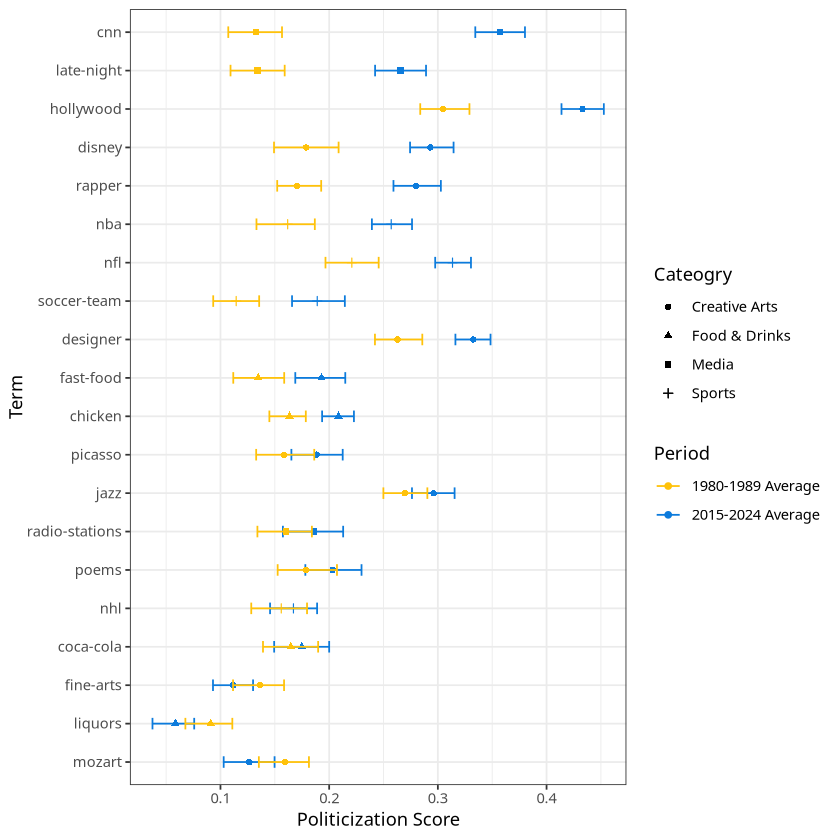

In [12]:
results_df_cat %>%
 filter(term %in% c("cnn", "radio-stations", "late-night", "designer",
                    "hollywood", "disney",  "poems",
                    "mozart", "fine-arts", "picasso", "rapper", "jazz",
                    "nba", "nfl", "soccer-team", "nhl", 
                     "chicken", "liquors", "fast-food", "coca-cola")) %>%
 group_by(term, group, Category) %>%
  summarise(
    late_value  = mean(pol_score[year >= 2015 & year <= 2024], na.rm = TRUE),
    early_value = mean(pol_score[year >= 1980 & year <= 1989], na.rm = TRUE),
    late_upper  = mean(pol_score_upper[year >= 2015 & year <= 2024], na.rm = TRUE),
    late_lower  = mean(pol_score_lower[year >= 2015 & year <= 2024], na.rm = TRUE),
    early_upper = mean(pol_score_upper[year >= 1980 & year <= 1989], na.rm = TRUE),
    early_lower = mean(pol_score_lower[year >= 1980 & year <= 1989], na.rm = TRUE)
  ) %>%
  ungroup() %>%
  filter(group == "ideology") %>%
  mutate(diff = late_value - early_value) %>%
  ggplot(aes(y = reorder(term, diff), shape = Category)) +
  geom_point(aes(x = late_value,  color = "2015-2024 Average")) +
  geom_errorbar(aes(xmin = late_lower, xmax = late_upper, color = "2015-2024 Average"), width = 0.3) +
  geom_point(aes(x = early_value, color = "1980-1989 Average")) +
  geom_errorbar(aes(xmin = early_lower, xmax = early_upper, color = "1980-1989 Average"), width = 0.3) +
  scale_color_manual(values = c("#FFC20A", "#0C7BDC")) +
  labs(x = "Politicization Score",
       y = "Term") +
  guides(shape = guide_legend(title = "Cateogry"),
         color = guide_legend(title = "Period")) +
  theme_bw(base_size = 11)

In [13]:
ggsave("lifestyle_term.png", width = 6.5, height = 7)

In [30]:
lifestyle_label <- 
    results_df_cat %>% 
    filter(Category %in% c("Creative Arts", "Media", "Sports", "Food & Drinks")) %>%
    distinct(label) %>%
    pull(label)

In [88]:
top_terms <- 
    dict_terms %>%
    filter(!term %in% c("zagat", "clear-channel")) %>% ## not present in both periods
    filter(label %in% lifestyle_label) %>%
    group_by(label) %>%
    slice_max(order_by = ratio , n=5) %>%
    ungroup()

`summarise()` has grouped output by 'label', 'group'. You can override using
the `.groups` argument.


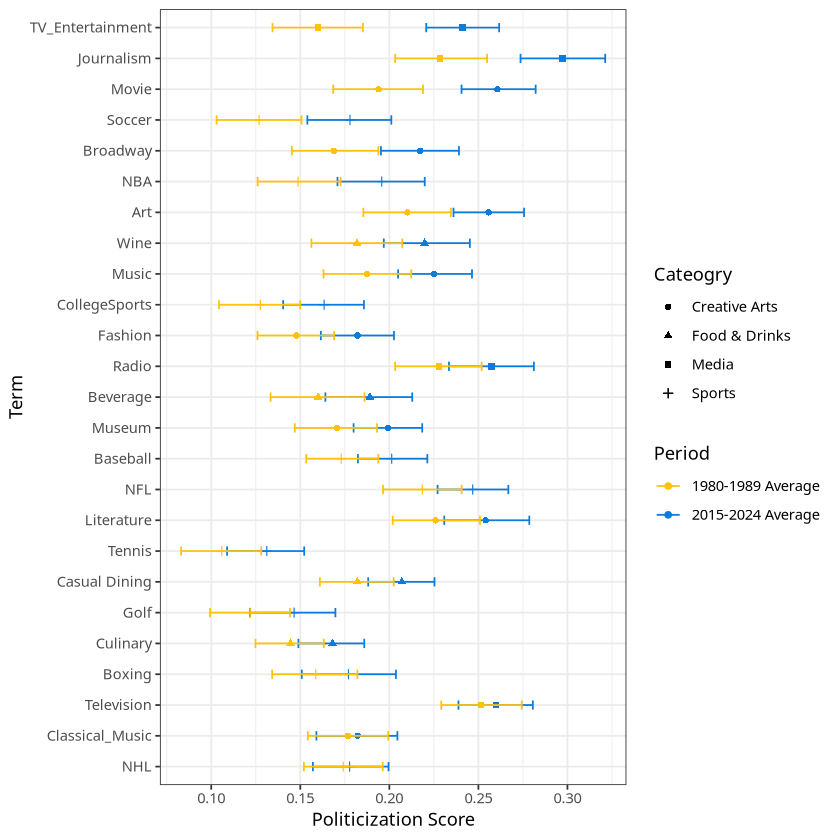

In [69]:
results_df_cat %>%
 filter(term %in% top_terms$term) %>%
 mutate(label = ifelse(label == "Dining", "Casual Dining", label)) %>%
 group_by(label, group, Category) %>%
  summarise(
    late_value  = mean(pol_score[year >= 2015 & year <= 2024], na.rm = TRUE),
    early_value = mean(pol_score[year >= 1980 & year <= 1989], na.rm = TRUE),
    late_upper  = mean(pol_score_upper[year >= 2015 & year <= 2024], na.rm = TRUE),
    late_lower  = mean(pol_score_lower[year >= 2015 & year <= 2024], na.rm = TRUE),
    early_upper = mean(pol_score_upper[year >= 1980 & year <= 1989], na.rm = TRUE),
    early_lower = mean(pol_score_lower[year >= 1980 & year <= 1989], na.rm = TRUE)
  ) %>%
  ungroup() %>%
  filter(group == "ideology") %>%
  mutate(diff = late_value - early_value) %>%
  ggplot(aes(y = reorder(label, diff), shape = Category)) +
  geom_point(aes(x = late_value,  color = "2015-2024 Average")) +
  geom_errorbar(aes(xmin = late_lower, xmax = late_upper, color = "2015-2024 Average"), width = 0.3) +
  geom_point(aes(x = early_value, color = "1980-1989 Average")) +
  geom_errorbar(aes(xmin = early_lower, xmax = early_upper, color = "1980-1989 Average"), width = 0.3) +
  scale_color_manual(values = c("#FFC20A", "#0C7BDC")) +
  labs(x = "Politicization Score",
       y = "Term") +
  guides(shape = guide_legend(title = "Cateogry"),
         color = guide_legend(title = "Period")) +
  theme_bw(base_size = 11)

In [70]:
ggsave("lifestyle_terms_top5.png", width = 6.5, height = 7)